# Proyek Klasifikasi Gambar: Plants Classification
- **Nama:** M. Sobahus Sururin Ni'am
- **Email:** sobahusn27@gmail.com
- **ID Dicoding:** https://www.dicoding.com/users/sobahusn/

## Import Semua Packages/Library yang Digunakan

In [3]:
# !pip install tensorflow tensorflowjs split-folder

In [4]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import split_folder

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [5]:
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Konfigurasi Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Dataset
!kaggle datasets download -d marquis03/plants-classification

# Extract Dataset
!unzip -q plants-classification.zip -d dataset

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/marquis03/plants-classification
License(s): apache-2.0
100% 1.34G/1.34G [01:23<00:00, 17.2MB/s]



### Data Preprocessing

#### Split Dataset

In [6]:
# Eksplorasi struktur dataset
base_path = 'dataset'
src_folders = ['train', 'val', 'test']

for folder in src_folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        classes = os.listdir(folder_path)
        total = sum(len(os.listdir(os.path.join(folder_path, c))) for c in classes if os.path.isdir(os.path.join(folder_path, c)))
        print(f"  {folder}: {len(classes)} kelas, {total} gambar")

  train: 31 kelas, 21000 gambar
  val: 31 kelas, 3000 gambar
  test: 31 kelas, 6000 gambar


In [7]:
# Menampilkan jumlah gambar per kelas (5 kelas pertama)
train_path = os.path.join(base_path, 'train')
selected_classes = sorted(os.listdir(train_path))[:5]

print("Kelas yang dipilih:", selected_classes)
print()

for folder in src_folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.isdir(folder_path):
        continue
    print(f"- {folder}")
    for cls in selected_classes:
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):
            print(f"  {cls}: {len(os.listdir(cls_path))} gambar")
    print()

Kelas yang dipilih: ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava']

- train
  aloevera: 700 gambar
  banana: 700 gambar
  bilimbi: 700 gambar
  cantaloupe: 700 gambar
  cassava: 700 gambar

- val
  aloevera: 100 gambar
  banana: 100 gambar
  bilimbi: 100 gambar
  cantaloupe: 100 gambar
  cassava: 100 gambar

- test
  aloevera: 200 gambar
  banana: 200 gambar
  bilimbi: 200 gambar
  cantaloupe: 200 gambar
  cassava: 200 gambar



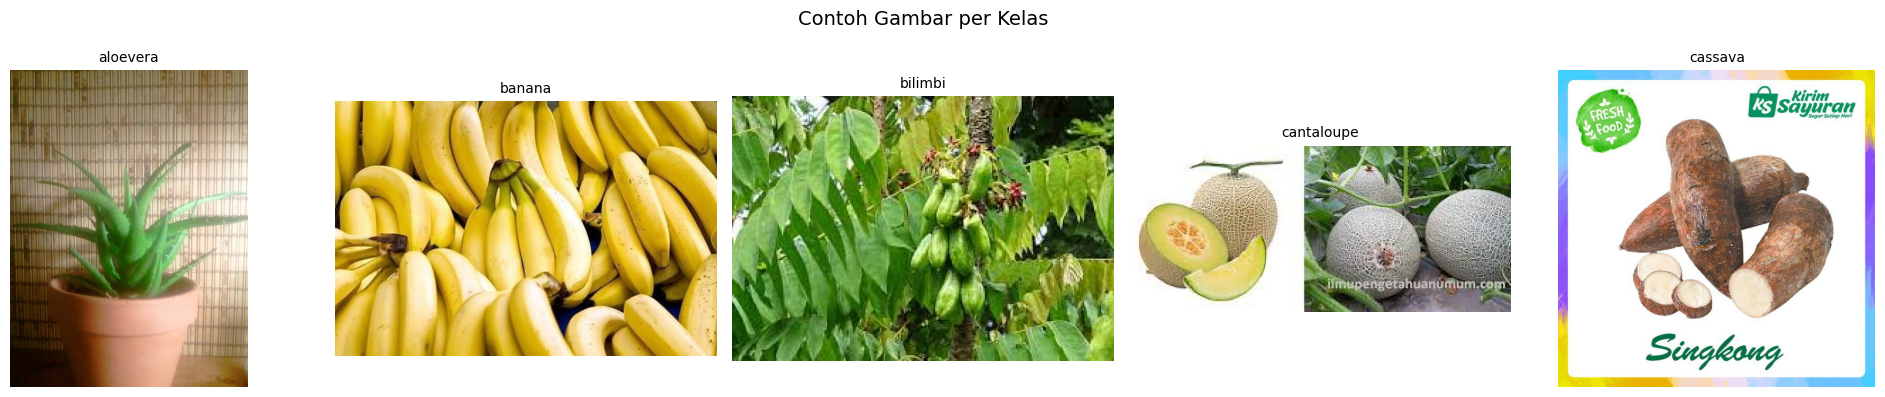

In [8]:
# Visualisasi contoh gambar dari setiap kelas
fig, axes = plt.subplots(1, len(selected_classes), figsize=(20, 4))
fig.suptitle('Contoh Gambar per Kelas', fontsize=14)

for i, cls in enumerate(selected_classes):
    cls_path = os.path.join(train_path, cls)
    img_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
# Menggabungkan semua split (train/val/test) jadi satu folder
combined_path = 'all_data'
os.makedirs(combined_path, exist_ok=True)

for folder in src_folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for class_name in selected_classes:
        src_class = os.path.join(folder_path, class_name)
        if not os.path.exists(src_class):
            continue

        dst_class = os.path.join(combined_path, class_name)
        os.makedirs(dst_class, exist_ok=True)

        for file in os.listdir(src_class):
            src_file = os.path.join(src_class, file)
            dst_file = os.path.join(dst_class, file)
            if not os.path.exists(dst_file):
                shutil.copy(src_file, dst_file)

# Verifikasi jumlah total gambar
total = 0
print("Jumlah Gambar per Kelas")
for cls in selected_classes:
    n = len(os.listdir(os.path.join(combined_path, cls)))
    print(f"  {cls}: {n}")
    total += n
print(f"  Total: {total}")

Jumlah Gambar per Kelas
  aloevera: 1000
  banana: 1000
  bilimbi: 1000
  cantaloupe: 1000
  cassava: 1000
  Total: 5000


In [10]:
# Split dataset: 70% train, 15% val, 15% test
split_folder.ratio(
    input=combined_path,
    output='split_dataset',
    seed=42,
    ratio=(.70, .15, .15)
)

train_dir = 'split_dataset/train'
val_dir   = 'split_dataset/val'
test_dir  = 'split_dataset/test'

print("Split selesai!")
for split, path in [('Train', train_dir), ('Val', val_dir), ('Test', test_dir)]:
    count = sum(len(os.listdir(os.path.join(path, c))) for c in os.listdir(path))
    print(f"  {split}: {count} gambar")


Copying (700) of .. train/aloevera



  0%|          | 0/700 [00:00<?, ?it/s]


Copying (150) of .. val/aloevera



  0%|          | 0/150 [00:00<?, ?it/s]


Copying (150) of .. test/aloevera



...


Copying (150) of .. val/banana



  0%|          | 0/150 [00:00<?, ?it/s]


Copying (150) of .. test/banana



  0%|          | 0/150 [00:00<?, ?it/s]

Split selesai!
  Train: 3500 gambar
  Val: 750 gambar
  Test: 750 gambar


### Data Augmentation

In [11]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

# Augmentasi hanya untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Val dan test HANYA rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nKelas:", train_generator.class_indices)

Found 3500 images belonging to 5 classes.
Found 750 images belonging to 5 classes.
Found 750 images belonging to 5 classes.

Kelas: {'aloevera': 0, 'banana': 1, 'bilimbi': 2, 'cantaloupe': 3, 'cassava': 4}


## Modelling

In [12]:
model = models.Sequential([
    # Blok 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Blok 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Blok 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Blok 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile Model

In [13]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,485 (2.00 MB)

 Trainable params: 523,525 (2.00 MB)

 Non-trainable params: 960 (3.75 KB)

None


## Callback Training

In [14]:
# Mendefinisikan Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

## Training Model

In [15]:
# Training Model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.5348 - loss: 1.2381
Epoch 1: val_accuracy improved from None to 0.20000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 56s 355ms/step - accuracy: 0.5877 - loss: 1.0958 - val_accuracy: 0.2000 - val_loss: 3.0757 - learning_rate: 0.0010
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.6530 - loss: 0.9287
Epoch 2: val_accuracy improved from 0.20000 to 0.25600, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 32s 295ms/step - accuracy: 0.6409 - loss: 0.9413 - val_accuracy: 0.2560 - val_loss: 2.7109 - learning_rate: 0.0010
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.6763 - loss: 0.8565
Epoch 3: val_accuracy did not improve from 0.25600
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 310ms/step - accuracy: 0.6800 - loss: 0.8309 - val_accuracy: 0.2267 - val_loss: 4.336

## Evaluasi dan Visualisasi

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8707 - loss: 0.3663
Test Accuracy: 87.07%


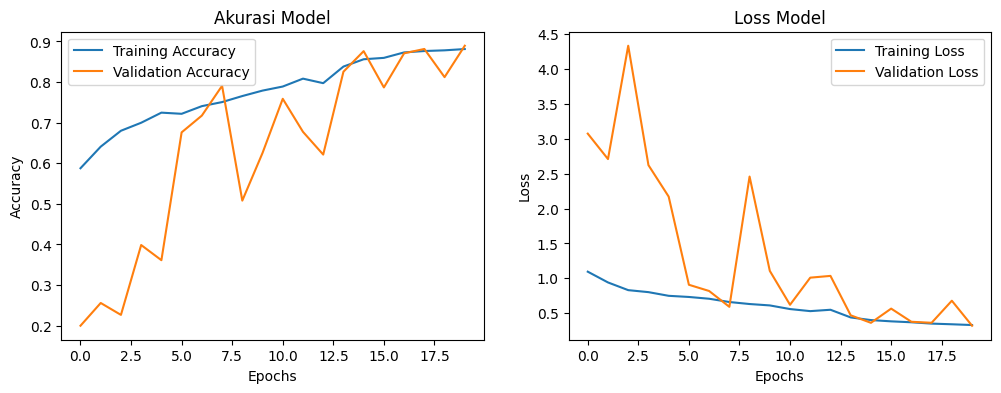

In [16]:
# Evaluasi pada Test Set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Visualisasi Akurasi dan Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot Akurasi
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Akurasi Model')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Loss Model')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

In [17]:
# Evaluasi test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"\nTest Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8707 - loss: 0.3663

Test Accuracy : 0.8707 (87.07%)
Test Loss     : 0.3663


## Classification Report


In [18]:
# Mendapatkan true labels dari test_generator
y_true = test_generator.classes

# Mendapatkan prediksi dari model
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

# Mendapatkan nama kelas
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step
              precision    recall  f1-score   support

    aloevera       0.81      0.92      0.86       150
      banana       0.80      0.91      0.85       150
     bilimbi       0.93      0.71      0.81       150
  cantaloupe       0.90      0.88      0.89       150
     cassava       0.94      0.93      0.94       150

    accuracy                           0.87       750
   macro avg       0.88      0.87      0.87       750
weighted avg       0.88      0.87      0.87       750



## Konversi Model

### Saved Model

In [19]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138092861361424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861363728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861365648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861363344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861363152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861364688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861365264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861365456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861367184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861367376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138092861366608: Te

### Konversi ke TensorFlow Lite (TFLite)

In [25]:
# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
tflite_model = converter.convert()

os.makedirs('tflite', exist_ok=True)

# Simpan model TFLite
with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

# Simpan label
with open('tflite/label.txt', 'w') as f:
    for class_name in sorted(train_generator.class_indices.keys()):
        f.write(class_name + '\n')

print("TFLite model tersimpan di: tflite/model.tflite")
print("Label tersimpan di: tflite/label.txt")
print(f"Ukuran model: {os.path.getsize('tflite/model.tflite') / 1024:.1f} KB")

TFLite model tersimpan di: tflite/model.tflite
Label tersimpan di: tflite/label.txt
Ukuran model: 2052.0 KB


### Konversi ke TensorFlow JS (TFJS)

In [26]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  saved_model \
  tfjs_model

2026-04-30 18:35:28.136486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777574128.171006   12368 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777574128.182306   12368 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777574128.208220   12368 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777574128.208253   12368 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777574128.208261   12368 computation_placer.cc:177] computation placer alr

## Inference (Optional)

Performing inference on: split_dataset/test/bilimbi/bilimbi14.jpg
True label: bilimbi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted class: bilimbi
Prediction probabilities: [0.04053781 0.02837946 0.729593   0.18966202 0.01182769]


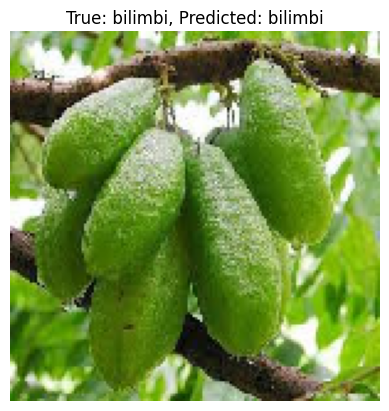

In [27]:
# Mendapatakan kelas dari train_generator untuk prediksi
class_names = list(train_generator.class_indices.keys())

# memilih gambar acak untuk inference
def get_random_test_image(test_dir, class_names):
    random_class = np.random.choice(class_names)
    class_path = os.path.join(test_dir, random_class)
    images_in_class = os.listdir(class_path)
    random_image_name = np.random.choice(images_in_class)
    return os.path.join(class_path, random_image_name), random_class

random_image_path, true_label = get_random_test_image(test_dir, class_names)
print(f"Performing inference on: {random_image_path}")
print(f"True label: {true_label}")

# Load and preprocess image
img = image.load_img(random_image_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array /= 255.0 # Rescale to [0, 1] as per ImageDataGenerator

# Membuat prediksi
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]
predicted_class_name = class_names[predicted_class_index]

print(f"Predicted class: {predicted_class_name}")
print(f"Prediction probabilities: {predictions[0]}")

plt.imshow(img)
plt.title(f"True: {true_label}, Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()